<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [20]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [21]:
# Posibles bandas
os.listdir("./songs_dataset/")

['prince.txt',
 'dickinson.txt',
 'notorious-big.txt',
 'beatles.txt',
 'bob-dylan.txt',
 'bjork.txt',
 'johnny-cash.txt',
 'disney.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'bob-marley.txt',
 'leonard-cohen.txt',
 'ludacris.txt',
 'adele.txt',
 'alicia-keys.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'lorde.txt',
 'rihanna.txt',
 'Kanye_West.txt',
 'nirvana.txt',
 'cake.txt',
 'bieber.txt',
 'notorious_big.txt',
 'missy-elliott.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'michael-jackson.txt',
 'al-green.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lin-manuel-miranda.txt',
 'nursery_rhymes.txt',
 'dj-khaled.txt',
 'radiohead.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'r-kelly.txt',
 'drake.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'nicki-minaj.txt',
 'kanye-west.txt',
 'paul-simon.txt',
 'nickelback.txt',
 'eminem.txt',
 'bruno-mars.txt']

In [22]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/var/folders/27/0slx3qhs2_99zptfvpy642qc0000gn/T/ipykernel_81156/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [23]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [24]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [25]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [26]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [27]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [28]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [29]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [30]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [31]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.2421875
Loss after epoch 1: 65966.5703125
Loss after epoch 2: 65935.015625
Loss after epoch 3: 65718.296875
Loss after epoch 4: 63874.96875
Loss after epoch 5: 64160.875
Loss after epoch 6: 64080.5
Loss after epoch 7: 64815.09375
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.75
Loss after epoch 10: 59839.6875
Loss after epoch 11: 58884.25
Loss after epoch 12: 57715.9375
Loss after epoch 13: 56494.1875
Loss after epoch 14: 55817.25
Loss after epoch 15: 55843.0625
Loss after epoch 16: 51722.6875
Loss after epoch 17: 49857.875
Loss after epoch 18: 49592.125
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [32]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954243063926697),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439376950263977),
 ('cry', 0.83512943983078),
 ('not', 0.8309614658355713),
 ('try', 0.8276940584182739),
 ('peace', 0.8144854307174683),
 ('little', 0.8140544295310974),
 ('twist', 0.8123906850814819),
 ('seems', 0.8079560995101929)]

In [33]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287278026342392),
 ('four', -0.23302021622657776),
 ('five', -0.237460196018219),
 ('six', -0.2378387749195099),
 ('bang', -0.2483242005109787),
 ('our', -0.25538891553878784),
 ('day', -0.2689763307571411),
 ('going', -0.2692073881626129),
 ('here', -0.26990994811058044),
 ('three', -0.28389739990234375)]

In [34]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813730716705322),
 ('three', 0.9745771884918213),
 ('six', 0.9710819721221924),
 ('seven', 0.9584385752677917),
 ('two', 0.9517235159873962),
 ('sixty', 0.8990404605865479),
 ('one', 0.7951188683509827),
 ('crying', 0.7946323752403259),
 ('us', 0.774010956287384),
 ("i'm", 0.7508406639099121)]

In [35]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434012770652771),
 ('buy', 0.9396973252296448),
 ('much', 0.9033190011978149),
 ('just', 0.8509107828140259),
 ('hide', 0.8355358839035034)]

In [36]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138294  0.05881053 -0.06370477  0.02445546 -0.20152311 -0.18612298
 -0.15284492  0.4548641  -0.042179    0.03535716  0.13657664 -0.1851985
 -0.18126567  0.22149132 -0.3038017  -0.23970504  0.0709474  -0.05679084
 -0.05165781 -0.23843321 -0.08529595  0.19564523 -0.07678778  0.03796823
  0.07516409 -0.04826145  0.07379413  0.10396487  0.00737745 -0.22765112
 -0.04566921  0.1293697   0.27785546  0.19387001 -0.13509622  0.20857269
  0.4091703  -0.00386562 -0.10631571 -0.09057102  0.02400816 -0.08005267
  0.13399461  0.08833719 -0.01894974  0.08592648 -0.15905555  0.10259393
  0.1445954  -0.1209247  -0.279195   -0.04061342  0.11381969  0.31366253
 -0.07408687  0.1397688   0.22791368  0.1320968  -0.01811604  0.09772383
  0.09249984 -0.14871608 -0.16348287 -0.13202605 -0.0983391   0.02714311
  0.16531329  0.2605218  -0.03259389 -0.02894598  0.11621305 -0.06974123
  0.09562718 -0.1527624   0.22071022  0.15996738  0.15890466 -0.04710886
 -0.12556134 -0.03993148 -0.10795182  0.01878742  0.

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0000001192092896),
 ('babe', 0.9085147380828857),
 ('someone', 0.8886134624481201),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085147380828857),
 ('someone', 0.8886134028434753),
 ('need', 0.8827983140945435),
 ('nothing', 0.8740261793136597),
 ("didn't", 0.8638365268707275),
 ("there's", 0.8526695370674133),
 ('you', 0.8456733226776123),
 ('feed', 0.844502866268158),
 ('somebody', 0.8362798094749451),
 ('buy', 0.8351726531982422)]

### 5 - Visualizar agrupación de vectores

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="vscode") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="vscode") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

## Corpus elegido Prince 🤴

Se utilizan las letras de Prince (`songs_dataset/prince.txt`) en lugar del corpus de
los Beatles visto en clase. La elección se basa en el tamaño: es el segundo archivo
más grande del dataset (~62.800 palabras frente a ~14.300 de Beatles), lo que permite
un vocabulario más amplio y vectores más estables.

Los embeddings resultantes no representan el idioma inglés en general, sino **el uso
particular que Prince hace de cada palabra en sus letras**. Esta distinción es clave
para interpretar los resultados: la similitud que mide el modelo es similitud de
contexto dentro de este corpus, no sinonimia.

In [ ]:
with open('songs_dataset/prince.txt', 'r') as f:
    prince_lyrics = f.read()

lines = [l for l in prince_lyrics.split('\n') if l.strip()]
print("Cantidad de documentos (versos):", len(lines))

Cantidad de documentos (versos): 9616


In [ ]:
#Hacemos la tokenización de los versos de Prince
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens_prince = [text_to_word_sequence(l) for l in lines]
sentence_tokens_prince[:2]


[['all', 'of', 'this', 'and', 'more', 'is', 'for', 'you'],
 ['with', 'love', 'sincerity', 'and', 'deepest', 'care']]

### Justificación de los hiperparámetros

Se parte de la configuración vista en clase y se ajusta según las características
del corpus:

| Parámetro | Clase | Acá | Motivo |
|---|---|---|---|
| `window` | 2 | 5 | Los versos promedian ⟨X⟩ palabras; una ventana de 5 cubre el verso completo |
| `vector_size` | 300 | ⟨100/300⟩ | ⟨justificar: 300 dimensiones para un corpus de ~63k tokens implica más parámetros que evidencia⟩ |
| `min_count` | 5 | 5 | Descarta palabras con muy pocas apariciones, que no llegan a formar un vector representativo |
| `sg` | 1 | 1 | Skipgram rinde mejor que CBOW en corpus pequeños |
| `seed` + `workers=1` | — | 42 / 1 | Reproducibilidad: con más de un worker el entrenamiento no es determinista y las interpretaciones escritas dejarían de corresponder a las salidas

In [ ]:
#Creamos el modelo generador de vectores para Prince en este caso utilizaremos la estructura modelo Skipgram
from gensim.models import Word2Vec

w2v_model = Word2Vec(min_count=5,
                     window=5,
                     vector_size=100,
                     negative=20,
                     workers=1,
                     sg=1,
                     seed=42)

w2v_model.build_vocab(sentence_tokens_prince)
print("Docs:", w2v_model.corpus_count)
print("Vocabulario:", len(w2v_model.wv.index_to_key))

vocab_total = len(set(w for doc in sentence_tokens_prince for w in doc))
print(f"Palabras distintas sin filtrar: {vocab_total}")
print(f"Retenidas con min_count=5: {len(w2v_model.wv.index_to_key)} "
      f"({len(w2v_model.wv.index_to_key)/vocab_total*100:.1f}%)")

Docs: 9616
Vocabulario: 1204
Palabras distintas sin filtrar: 4080
Retenidas con min_count=5: 1204 (29.5%)


**Resultado:** 9.616 documentos y 1.204 palabras distintas en el vocabulario.

El vocabulario casi triplica el del ejemplo de clase con los Beatles (445 palabras),
lo que era el objetivo al elegir un corpus más extenso: con más palabras representadas
y más contexto por palabra, los vectores resultantes son más estables y la proyección
posterior tiene más estructura para mostrar.

Notar que 1.204 es el vocabulario *después* del filtro `min_count=5`: la cantidad de
palabras distintas en el texto crudo es bastante mayor, pero las que aparecen menos de
cinco veces se descartan por no tener contexto suficiente.

### 3 - Entrenar embeddings

Hasta acá el modelo sólo conoce el vocabulario: los vectores están inicializados al
azar. El entrenamiento es el que les da forma, recorriendo el corpus y ajustando cada
vector para que prediga mejor las palabras que lo rodean.

Se entrena durante 30 épocas, más que las 20 del ejemplo de clase, porque el corpus
sigue siendo pequeño (~63.000 tokens) y cada época aporta relativamente poca
información: con pocas pasadas los vectores no alcanzan a diferenciarse.

Gensim no informa el loss durante el entrenamiento, así que se sobrecarga el callback
`CallbackAny2Vec` para imprimirlo al final de cada época y poder verificar que el
modelo efectivamente está aprendiendo.

In [ ]:
from gensim.models.callbacks import CallbackAny2Vec

class callback(CallbackAny2Vec):
    """Imprime el loss al final de cada época"""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

w2v_model.train(sentence_tokens_prince,
                total_examples=w2v_model.corpus_count,
                epochs=30,
                compute_loss=True,
                callbacks=[callback()])

Loss after epoch 0: 592965.9375
Loss after epoch 1: 477718.1875
Loss after epoch 2: 427203.875
Loss after epoch 3: 407678.875
Loss after epoch 4: 372803.875
Loss after epoch 5: 343235.5
Loss after epoch 6: 339133.5
Loss after epoch 7: 333362.5
Loss after epoch 8: 326699.5
Loss after epoch 9: 324303.0
Loss after epoch 10: 317134.25
Loss after epoch 11: 295484.5
Loss after epoch 12: 295847.0
Loss after epoch 13: 292230.0
Loss after epoch 14: 291606.0
Loss after epoch 15: 290670.5
Loss after epoch 16: 289100.5
Loss after epoch 17: 289361.5
Loss after epoch 18: 286245.0
Loss after epoch 19: 284432.0
Loss after epoch 20: 282872.5
Loss after epoch 21: 284184.0
Loss after epoch 22: 282640.5
Loss after epoch 23: 283763.5
Loss after epoch 24: 284190.0
Loss after epoch 25: 269918.5
Loss after epoch 26: 262788.0
Loss after epoch 27: 263235.0
Loss after epoch 28: 263647.0
Loss after epoch 29: 263262.0


(1228633, 1894530)

**Evolución del loss:** el loss desciende de 592.966 a 263.262, una reducción del 56%.
La caída es pronunciada en las primeras cinco épocas (-42%), continúa de forma gradual
hasta la época 25 y se estanca a partir de la 26: las últimas cuatro épocas varían
menos del 1% entre sí. Esto indica que 30 épocas son suficientes para este corpus y que
agregar más no aportaría mejoras sustanciales.

Las subidas puntuales en algunas épocas (12, 17, 21, 23) corresponden a la variabilidad
propia del negative sampling, que en cada pasada muestrea un conjunto distinto de
palabras negativas; no indican un problema de entrenamiento.

El valor de la primera época es el más alto porque los vectores todavía están
inicializados al azar y el modelo no aprendió ninguna estructura del corpus.

### 4 - Ensayar

Con los vectores ya entrenados se exploran las relaciones que el modelo aprendió.

`most_similar` calcula la similitud coseno entre vectores, es decir, el ángulo entre
ellos. Es importante precisar qué significa eso acá: **dos palabras resultan similares
si aparecen rodeadas de las mismas palabras en el corpus**, no si son sinónimos. La
similitud que mide el modelo es de contexto de uso, y el contexto es el de las letras
de Prince exclusivamente.

Se eligen términos característicos del corpus en lugar de palabras genéricas: una
palabra muy frecuente y poco específica (artículos, preposiciones) aparece en todos los
contextos y su vecindario no admite interpretación.

In [ ]:
terminos = ["purple", "love", "god", "money", "night", "dance"]

for t in terminos:
    print(f"\n--- {t} ---")
    if t in w2v_model.wv:
        for palabra, sim in w2v_model.wv.most_similar(positive=[t], topn=10):
            print(f"   {palabra:20s} {sim:.3f}")
    else:
        print("   (fuera de vocabulario)")


--- purple ---
   laughing             0.717
   rain                 0.683
   ladder               0.611
   fade                 0.603
   thunder              0.577
   falling              0.567
   seesaw               0.565
   ooooo                0.554
   fighting             0.541
   floor                0.539

--- love ---
   which                0.489
   decide               0.488
   undress              0.477
   awake                0.476
   miss                 0.475
   forever              0.470
   9's                  0.466
   affair               0.464
   loving               0.453
   internal             0.453

--- god ---
   created              0.660
   shed                 0.618
   those                0.598
   swear                0.562
   grace                0.558
   lot                  0.537
   plain                0.518
   background           0.512
   shoes                0.510
   above                0.506

--- money ---
   yesterday            0.709
   matter   

#### Términos más similares

El modelo capta sobre todo coocurrencia literal: `purple` → `laughing`, `rain` sale del
verso "laughing in the purple rain", y `money` → `yesterday`, `matter` de "Money don't
matter 2 night". Sólo `dance` (`romance`, `booty`, `dancer`) refleja un campo semántico
distribuido en varias canciones.

`love`, la palabra más frecuente (596 apariciones), tiene el vecindario menos
interpretable: aparece en demasiados contextos y su vector queda como promedio de todos.

In [ ]:
#Vamos a ver tambien los menos similares

w2v_model.wv.most_similar(negative=["love"], topn=10)

[('big', 0.0408795103430748),
 ("'til", 0.03518308326601982),
 ('straight', -0.013923676684498787),
 ('then', -0.03148718550801277),
 ('place', -0.03855721652507782),
 ('ocean', -0.049060191959142685),
 ('move', -0.05450284108519554),
 ('mind', -0.056781116873025894),
 ('his', -0.063954658806324),
 ('hip', -0.06538808345794678)]

#### Términos menos similares

Las similitudes van de 0.04 a -0.07: no son antónimos sino vectores ortogonales,
palabras sin relación con `love`. Word2Vec no modela oposición semántica, por lo que
estos resultados son poco informativos.

In [ ]:
palabra = "krankenhause"

if palabra in w2v_model.wv:
    print(w2v_model.wv.most_similar(palabra))
else:
    print(f"'{palabra}' no está en el vocabulario (OOV)")

'krankenhause' no está en el vocabulario (OOV)


#### Palabra fuera de vocabulario (OOV)

Word2Vec asigna un vector por palabra completa, así que sólo representa lo que vio en
entrenamiento: ante una palabra desconocida no tiene nada que devolver. FastText sí
resolvería este caso, porque compone el vector a partir de n-gramas de caracteres.

### 5 - Visualizar agrupación de vectores

Los vectores tienen 100 dimensiones y hay que llevarlos a 2 para graficarlos. Esa
compresión pierde información y cada algoritmo elige qué conservar: t-SNE preserva
vecindarios locales, es decir, qué palabras quedaron cerca de cuáles.

En consecuencia, del gráfico sólo son interpretables los grupos de palabras próximas
entre sí. La distancia entre grupos alejados, los ejes (que no tienen unidades) y la
densidad de los grupos no representan nada.

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import plotly.express as px

def reduce_dimensions(model, num_dimensions=2, perplexity=30, random_state=0):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, perplexity=perplexity,
                random_state=random_state, init='pca')
    return tsne.fit_transform(vectors), labels

vecs, labels = reduce_dimensions(w2v_model)

INICIO, FIN = 100, 300   # salteo las 100 más frecuentes

fig = px.scatter(x=vecs[INICIO:FIN, 0], y=vecs[INICIO:FIN, 1],
                 text=labels[INICIO:FIN])
fig.update_traces(textposition='top center', marker=dict(size=5))
fig.update_layout(height=700)
fig.show()

In [ ]:
print("Descartadas:", list(labels[:INICIO]))
print("\nGraficadas:", list(labels[INICIO:FIN]))

Descartadas: [np.str_('the'), np.str_('u'), np.str_('i'), np.str_('a'), np.str_('2'), np.str_('and'), np.str_('me'), np.str_('it'), np.str_('in'), np.str_('your'), np.str_('that'), np.str_('my'), np.str_('love'), np.str_('do'), np.str_('all'), np.str_('we'), np.str_('you'), np.str_('on'), np.str_('yeah'), np.str_('baby'), np.str_('be'), np.str_('is'), np.str_('of'), np.str_("don't"), np.str_('to'), np.str_('4'), np.str_("i'm"), np.str_('so'), np.str_('if'), np.str_('go'), np.str_('come'), np.str_('oh'), np.str_('just'), np.str_('this'), np.str_('what'), np.str_('with'), np.str_('got'), np.str_('no'), np.str_('when'), np.str_('can'), np.str_('like'), np.str_('get'), np.str_('say'), np.str_('will'), np.str_('wanna'), np.str_('know'), np.str_("it's"), np.str_('up'), np.str_('time'), np.str_('but'), np.str_('want'), np.str_('gonna'), np.str_('down'), np.str_('la'), np.str_('now'), np.str_('are'), np.str_("can't"), np.str_('was'), np.str_("i'll"), np.str_('see'), np.str_('they'), np.str_('t

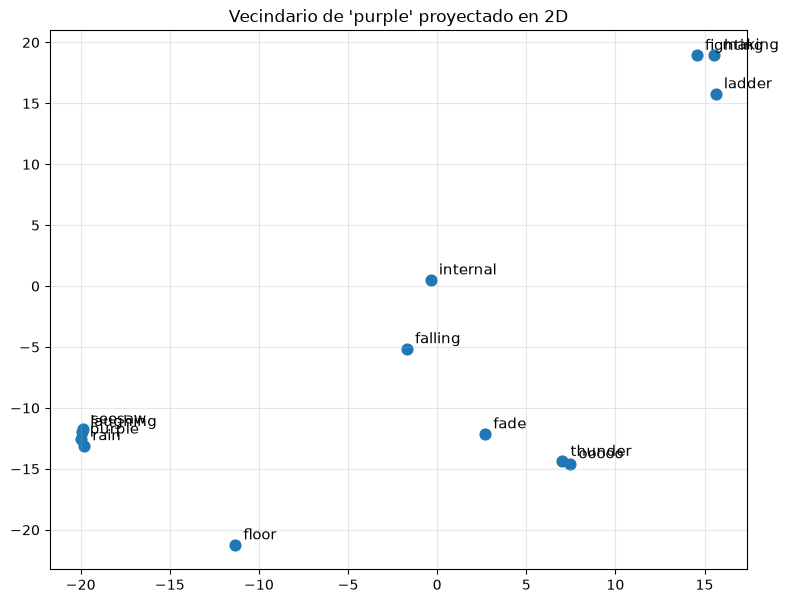

In [ ]:
import matplotlib.pyplot as plt

pos = {w: i for i, w in enumerate(labels)}

def zoom(semilla, topn=12):
    palabras = [semilla] + [w for w, _ in w2v_model.wv.most_similar(semilla, topn=topn)]
    idx = [pos[w] for w in palabras]
    P = vecs[idx]

    plt.figure(figsize=(9, 7))
    plt.scatter(P[:, 0], P[:, 1], s=60)
    for j, w in enumerate(palabras):
        plt.annotate(w, (P[j, 0], P[j, 1]), fontsize=11,
                     xytext=(6, 4), textcoords='offset points')
    plt.title(f"Vecindario de '{semilla}' proyectado en 2D")
    plt.grid(alpha=0.3)
    plt.show()

zoom("purple")

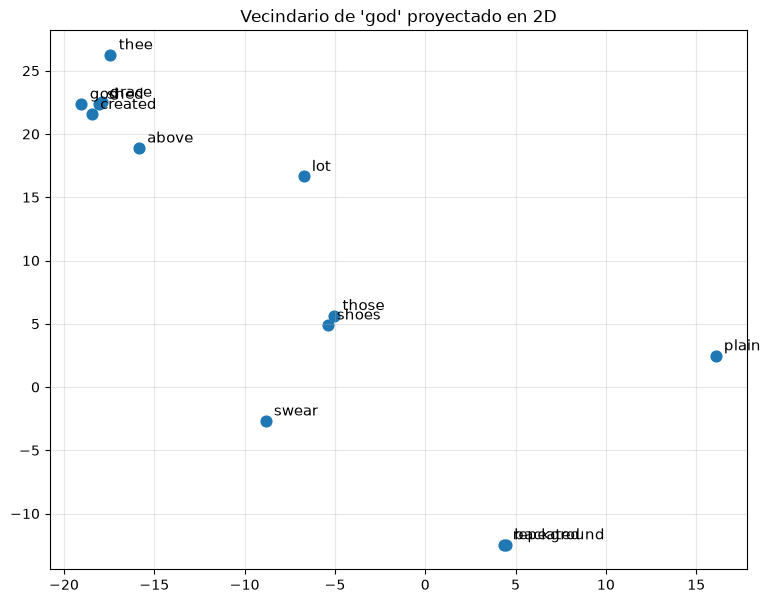

In [ ]:
import matplotlib.pyplot as plt

pos = {w: i for i, w in enumerate(labels)}

def zoom(semilla, topn=12):
    palabras = [semilla] + [w for w, _ in w2v_model.wv.most_similar(semilla, topn=topn)]
    idx = [pos[w] for w in palabras]
    P = vecs[idx]

    plt.figure(figsize=(9, 7))
    plt.scatter(P[:, 0], P[:, 1], s=60)
    for j, w in enumerate(palabras):
        plt.annotate(w, (P[j, 0], P[j, 1]), fontsize=11,
                     xytext=(6, 4), textcoords='offset points')
    plt.title(f"Vecindario de '{semilla}' proyectado en 2D")
    plt.grid(alpha=0.3)
    plt.show()

zoom("god")

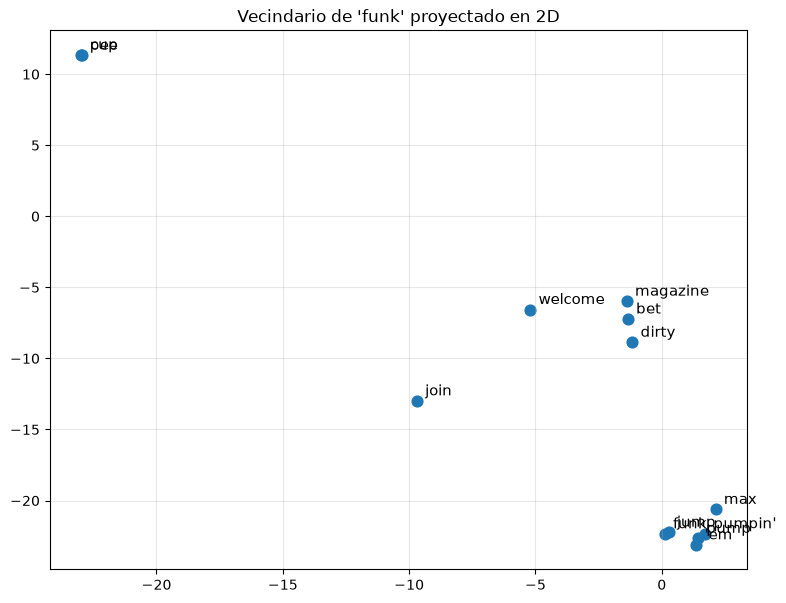

In [ ]:
import matplotlib.pyplot as plt

pos = {w: i for i, w in enumerate(labels)}

def zoom(semilla, topn=12):
    palabras = [semilla] + [w for w, _ in w2v_model.wv.most_similar(semilla, topn=topn)]
    idx = [pos[w] for w in palabras]
    P = vecs[idx]

    plt.figure(figsize=(9, 7))
    plt.scatter(P[:, 0], P[:, 1], s=60)
    for j, w in enumerate(palabras):
        plt.annotate(w, (P[j, 0], P[j, 1]), fontsize=11,
                     xytext=(6, 4), textcoords='offset points')
    plt.title(f"Vecindario de '{semilla}' proyectado en 2D")
    plt.grid(alpha=0.3)
    plt.show()

zoom("funk")

### Análisis de los grupos


**"Purple Rain".** `purple`, `rain`, `laughing` y `seesaw` quedan prácticamente
superpuestos, por el verso "I only want to see you laughing in the purple rain".
`seesaw` no comparte línea con `purple` sino con `laughing` ("The girl on the seesaw is
laughing"): el modelo lo acerca de forma indirecta, por contexto compartido.

**Líneas religiosas.** `god`, `shed`, `grace`, `created` y `thee` forman el grupo más
compacto de la proyección. No es un campo semántico religioso general sino dos versos
repetidos literalmente: "God shed his grace on thee" y "And God created woman".

**Funk.** `funk`, `funky` y `pumpin'` quedan juntos, pero el grupo es mucho más laxo:
sus palabras no vienen de un verso repetido sino de apariciones distribuidas en varias
canciones, con contextos más variados.

En los tres casos, los vecinos que `most_similar` reportaba con similitudes medias
(`ladder`, `those`, `shoes`, `pop`) aparecen dispersos en el plano. La proyección a 2D
conserva únicamente el núcleo de vecinos más próximos, así que sólo ese núcleo admite
interpretación.

**Conclusión de la sección:** los agrupamientos más fuertes del modelo son los que nacen
de repetición literal en el corpus, no de proximidad temática. Con un corpus de este
tamaño, Word2Vec memoriza estribillos antes que aprender campos semánticos.

## Conclusiones

**Sobre el corpus.** Las letras de Prince dieron 9.616 versos y un vocabulario de 1.204
palabras con `min_count=5`, casi el triple que el ejemplo de clase con los Beatles (445).
Aun así sigue siendo un corpus pequeño, y ese tamaño condiciona todo lo observado.

**Sobre lo que el modelo aprendió.** Las asociaciones más fuertes no son semánticas sino
de coocurrencia literal: `purple`–`rain`–`laughing` viene de un estribillo, `god`–`shed`–
`grace` de dos versos repetidos, `money`–`matter`–`yesterday` de "Money don't matter 2
night". Sólo `dance` y `funk` reflejan algo parecido a un campo semántico. Con esta
cantidad de datos, Word2Vec memoriza estribillos antes que aprender conceptos.

**Sobre la frecuencia.** `love` es la palabra más frecuente del corpus (596 apariciones)
y tiene el vecindario menos interpretable, con similitudes bajas y vecinos sin relación
aparente; `purple`, con 34 apariciones concentradas en pocos versos, tiene un vector
mucho más definido. La calidad de un embedding depende de la concentración de sus
contextos, no de su frecuencia.

**Sobre la visualización.** Al graficar las palabras más frecuentes no se distinguía
ningún grupo, porque las más frecuentes son palabras funcionales que aparecen en todos
los contextos; fue necesario saltear las primeras 100 para que emergiera estructura. El
mismo efecto se repite dentro del gráfico: el centro concentra las palabras sin contexto
propio y los grupos interpretables quedan en la periferia. Además, sólo el núcleo de
vecinos más próximos sobrevive a la proyección, de modo que el gráfico sirve para
detectar candidatos a grupo, mientras que la verificación se hace con `most_similar`.

**Limitaciones y mejoras posibles.** El modelo no puede representar palabras fuera de su
vocabulario, cosa que FastText sí resolvería mediante n-gramas de caracteres. Para
mejorar los resultados convendría ampliar el corpus —combinando varios artistas del mismo
género— y normalizar las grafías propias del autor (Prince escribe "2 night" por
"tonight", "u" por "you"), que actualmente fragmentan el vocabulario.